In [76]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


In [77]:
#load the dataset
data = pd.read_csv('embedded_system_network_security_dataset.csv')

In [78]:
data.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   label                  1000 non-null   float64
 9   protocol_type_TCP      1000 non-null   bool   
 10  protocol_type_UDP      1000 non-null   bool   
 11  src_ip_192.168.1.2     1000 non-null   bool   
 12  src_ip_192.168.1.3     1000 non-null   bool   
 13  dst_ip_192.168.1.5     1000 non-null   bool   
 14  dst_ip_192.168.1.6     1000 non-null   bool   
 15  tcp_f

In [80]:
#convert boolean labels to integers if present
for column in data.columns:
    if data[column].dtype == 'bool':
        data[column] = data[column].astype(int)

In [81]:
data.isna().sum()

packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
dtype: int64

In [82]:
#convert to dataframe
df = pd.DataFrame(data)

### Feature engineering

In [83]:
#selecting features for anomaly detection
features = data.drop(columns = ['label'])
features.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0,1,1,0,0,0,0,0,0
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0,1,0,0,0,1,0,1,0
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0,1,0,0,1,0,0,0,0
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0,0,0,1,0,0,0,0,0
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,1,0,0,1,0,0,0,1,0


In [84]:
#convert boolean labels to integers if present
for column in features.columns:
    if features[column].dtype == 'bool':
        features[column] = features[column].astype(int)

In [85]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   packet_size            1000 non-null   float64
 1   inter_arrival_time     1000 non-null   float64
 2   src_port               1000 non-null   int64  
 3   dst_port               1000 non-null   int64  
 4   packet_count_5s        1000 non-null   float64
 5   mean_packet_size       1000 non-null   float64
 6   spectral_entropy       1000 non-null   float64
 7   frequency_band_energy  1000 non-null   float64
 8   protocol_type_TCP      1000 non-null   int32  
 9   protocol_type_UDP      1000 non-null   int32  
 10  src_ip_192.168.1.2     1000 non-null   int32  
 11  src_ip_192.168.1.3     1000 non-null   int32  
 12  dst_ip_192.168.1.5     1000 non-null   int32  
 13  dst_ip_192.168.1.6     1000 non-null   int32  
 14  tcp_flags_FIN          1000 non-null   int32  
 15  tcp_f

In [86]:
#scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features

array([[-0.33611459,  0.38472447,  1.65001067, ..., -0.57888987,
        -0.55424682, -0.58504861],
       [ 0.08675815,  0.81508034,  1.4778486 , ..., -0.57888987,
         1.8042503 , -0.58504861],
       [-0.95434959, -0.09659806,  1.80747926, ..., -0.57888987,
        -0.55424682, -0.58504861],
       ...,
       [ 1.55568452,  0.78180053,  1.16048051, ..., -0.57888987,
        -0.55424682, -0.58504861],
       [-0.62050269,  0.51131651, -0.79785621, ..., -0.57888987,
        -0.55424682,  1.70925967],
       [-1.12498245, -1.16074428, -1.31931225, ..., -0.57888987,
         1.8042503 , -0.58504861]])

In [87]:
#convert scaled features back to dataframe
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,-0.336115,0.384724,1.650011,1.351370,1.155602,0.0,1.157333,0.166460,-0.671847,1.347925,1.471243,-0.714545,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049
1,0.086758,0.815080,1.477849,1.351370,0.919957,0.0,-1.188696,1.707564,-0.671847,1.347925,-0.679697,-0.714545,-0.712949,1.383999,-0.57889,1.804250,-0.585049
2,-0.954350,-0.096598,1.807479,-0.665426,-0.729556,0.0,1.229489,-1.534356,-0.671847,1.347925,-0.679697,-0.714545,1.402626,-0.722544,-0.57889,-0.554247,-0.585049
3,0.245026,-0.218135,1.063244,-0.815436,-1.200846,0.0,-1.168120,-1.067234,-0.671847,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049
4,0.514577,1.339842,-0.276022,-0.815436,0.684312,0.0,1.464215,0.224480,1.488433,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,1.804250,-0.585049


In [88]:
#parameters required for isolation forest
model = IsolationForest(n_estimators = 100, contamination = 0.04, max_samples= 256,random_state = 42)

In [94]:
model.fit(scaled_df)
anomaly_labels = model.predict(scaled_df)
#-1 for anomalies and 1 for normal data points
anomaly_labels

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1

In [95]:
#create a new column in the original dataframe to store anomaly labels
scaled_df['anomaly'] = anomaly_labels
scaled_df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK,anomaly
0,-0.336115,0.384724,1.650011,1.351370,1.155602,0.0,1.157333,0.166460,-0.671847,1.347925,1.471243,-0.714545,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049,1
1,0.086758,0.815080,1.477849,1.351370,0.919957,0.0,-1.188696,1.707564,-0.671847,1.347925,-0.679697,-0.714545,-0.712949,1.383999,-0.57889,1.804250,-0.585049,1
2,-0.954350,-0.096598,1.807479,-0.665426,-0.729556,0.0,1.229489,-1.534356,-0.671847,1.347925,-0.679697,-0.714545,1.402626,-0.722544,-0.57889,-0.554247,-0.585049,1
3,0.245026,-0.218135,1.063244,-0.815436,-1.200846,0.0,-1.168120,-1.067234,-0.671847,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049,1
4,0.514577,1.339842,-0.276022,-0.815436,0.684312,0.0,1.464215,0.224480,1.488433,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,1.804250,-0.585049,1


In [96]:
#check how many anomalies and normal data points we have
scaled_df['anomaly'].value_counts()

anomaly
 1    960
-1     40
Name: count, dtype: int64

Text(0.5, 1.0, 'Anomaly Detection in Network Traffic')

Text(0.5, 1.0, 'Anomaly Detection in Network Traffic')

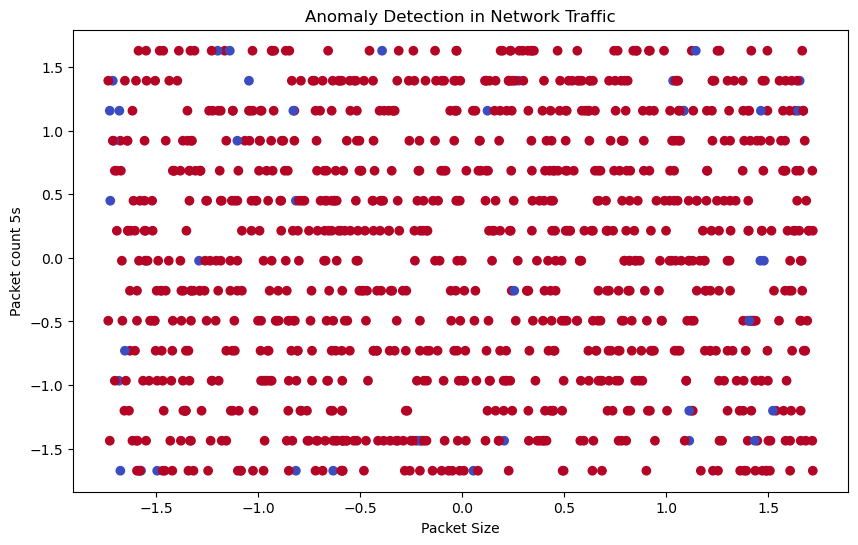

In [99]:
#visualize anomalies
plt.figure(figsize=(10,6))
plt.scatter(scaled_df['packet_size'], scaled_df['packet_count_5s'], c=scaled_df['anomaly'], cmap='coolwarm')
plt.xlabel('Packet Size')
plt.ylabel('Packet count 5s')
plt.title('Anomaly Detection in Network Traffic')

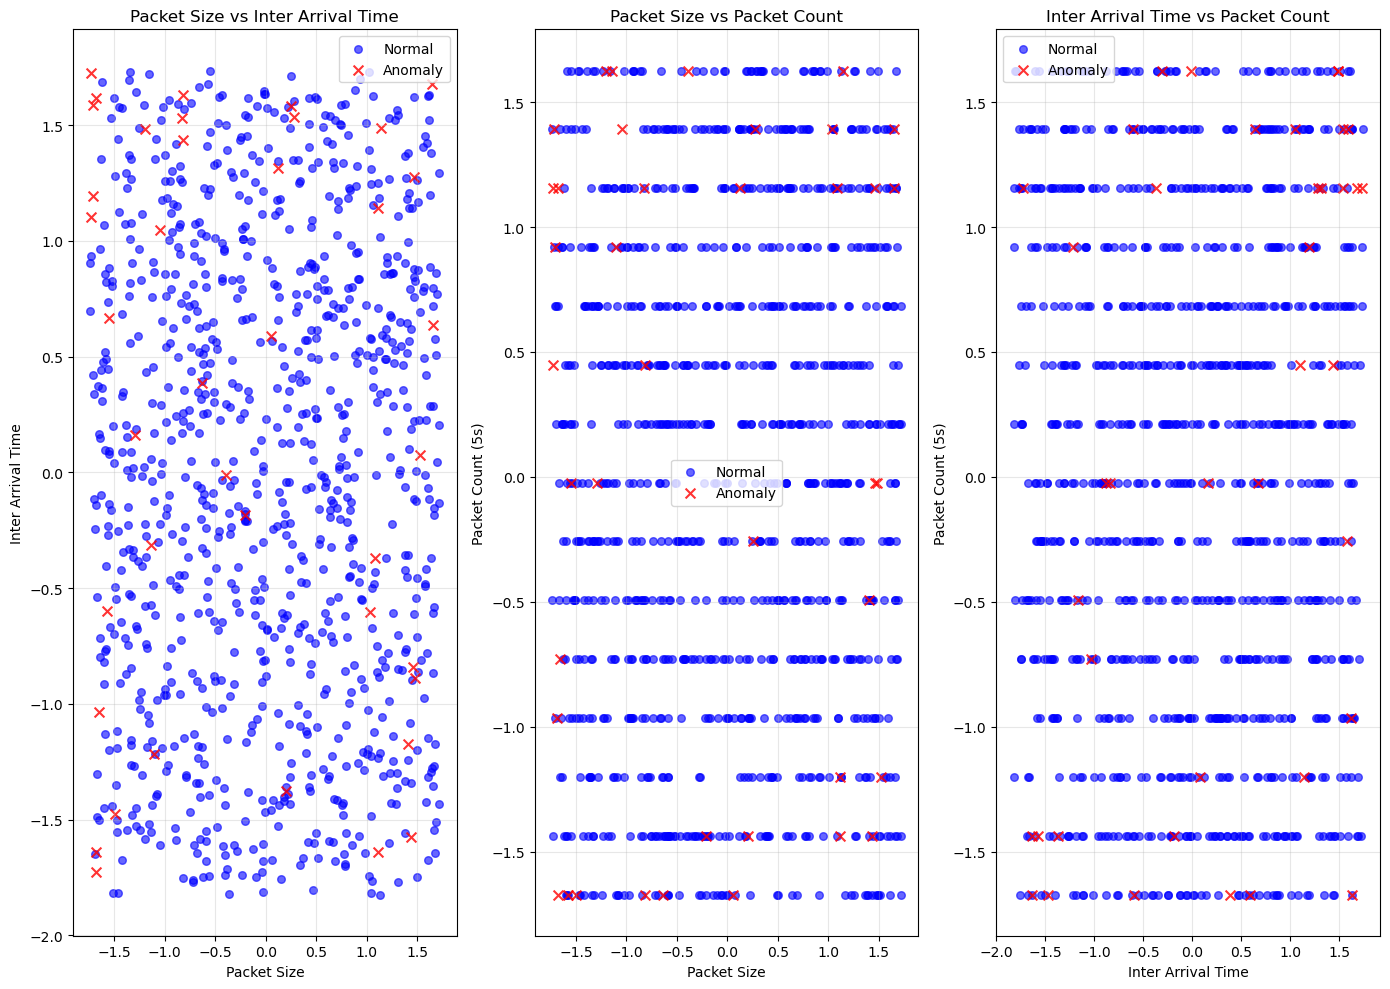

In [103]:
#separate normal and anomaly data
normal = scaled_df[scaled_df['anomaly'] == 1]
anomaly = scaled_df[scaled_df['anomaly'] == -1]

#visualize all 4 columns - comprehensive view 
fig, axes = plt.subplots(1, 3, figsize=(14, 10))

# Plot 1: packet_size vs inter_arrival_time
axes[0].scatter(normal['packet_size'], normal['inter_arrival_time'], color='blue', label='Normal', alpha=0.6, s=30)
axes[0].scatter(anomaly['packet_size'], anomaly['inter_arrival_time'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[0].set_xlabel('Packet Size')
axes[0].set_ylabel('Inter Arrival Time')
axes[0].set_title('Packet Size vs Inter Arrival Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: packet_size vs packet_count_5s
axes[1].scatter(normal['packet_size'], normal['packet_count_5s'], color='blue', label='Normal', alpha=0.6, s=30)
axes[1].scatter(anomaly['packet_size'], anomaly['packet_count_5s'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[1].set_xlabel('Packet Size')
axes[1].set_ylabel('Packet Count (5s)')
axes[1].set_title('Packet Size vs Packet Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: inter_arrival_time vs packet_count_5s
axes[2].scatter(normal['inter_arrival_time'], normal['packet_count_5s'], color='blue', label='Normal', alpha=0.6, s=30)
axes[2].scatter(anomaly['inter_arrival_time'], anomaly['packet_count_5s'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[2].set_xlabel('Inter Arrival Time')
axes[2].set_ylabel('Packet Count (5s)')
axes[2].set_title('Inter Arrival Time vs Packet Count')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
#4D visualization using 3D scatter plot with color as 4th dimension
import plotly.graph_objects as go
import numpy as np

# Separate normal and anomaly from scaled data
normal = scaled_df[scaled_df['anomaly'] == 1]
anomaly = scaled_df[scaled_df['anomaly'] == -1]

fig = go.Figure()

# Normal points
fig.add_trace(go.Scatter3d(
    x=normal['packet_size'],
    y=normal['inter_arrival_time'],
    z=normal['packet_count_5s'],
    mode='markers',
    name='Normal',
    marker=dict(
        size=5,
        color='blue',
        opacity=0.6
    )
))

# Anomaly points
fig.add_trace(go.Scatter3d(
    x=anomaly['packet_size'],
    y=anomaly['inter_arrival_time'],
    z=anomaly['packet_count_5s'],
    mode='markers',
    name='Anomaly',
    marker=dict(
        size=8,
        color='red',
        opacity=0.9,
        symbol='diamond'
    )
))

# Layout
fig.update_layout(
    title='3D Network Traffic Anomaly Detection<br>(Packet Size, Inter Arrival Time, Packet Count)',
    scene=dict(
        xaxis_title='Packet Size (scaled)',
        yaxis_title='Inter Arrival Time (scaled)',
        zaxis_title='Packet Count 5s (scaled)'
    ),
    width=900,
    height=700
)

fig.show()

In [105]:
#save the model
import joblib
joblib.dump(model, 'isolation_forest_model.pkl')

['isolation_forest_model.pkl']